# TCGA Mutation Processing (Xena)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import os

SAVE_DIR = "data/tcga"
os.makedirs(SAVE_DIR, exist_ok=True)

## Construction of mutation matrix:

X_{g,s} = number of mutations in gene g for sample s

This is the base representation of somatic mutations.


In [2]:
PHENO_FILE = "../data/_phenotype/TCGA_phenotype_denseDataOnlyDownload.tsv.gz"
maf_file = "../data/_maf_mc3/mc3.v0.2.8.PUBLIC.maf"
maf = pd.read_csv(maf_file, sep="\t", comment="#", low_memory=False)
maf = maf[["Hugo_Symbol","Tumor_Sample_Barcode","Variant_Classification"]]
maf["Sample"] = maf["Tumor_Sample_Barcode"].str[:15]
maf.rename(columns={"Hugo_Symbol":"Gene"}, inplace=True)

In [3]:
COLORS = {
    0: '#0077B6',   1: '#0000FF',   2: '#00B4D8',   3: '#48EAC4',
    4: '#F1C0E8',   5: '#B9FBC0',   6: '#32CD32',   7: '#BEE1E6',
    8: '#8A2BE2',   9: '#E377C2',  10: '#8EECF5',  11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700',  14: '#FF69B4',  15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50',  18: '#C71585',  19: '#20B2AA',
    20: '#6A5ACD', 21: '#40E0D0',  22: '#FF8C00',  23: '#DC143C',
    24: '#9ACD32',
    25: '#1F77B4', 26: '#FF1493', 27: '#2E8B57', 28: '#D2691E',
    29: '#9932CC', 30: '#00CED1', 31: '#FF4500', 32: '#708090'
}


disease_to_tcga = {
    "adrenocortical carcinoma": "ACC",
    "bladder urothelial carcinoma": "BLCA",
    "breast invasive carcinoma": "BRCA",
    "cervical squamous cell carcinoma and endocervical adenocarcinoma": "CESC",
    "cholangiocarcinoma": "CHOL",
    "colon adenocarcinoma": "COAD",
    "rectum adenocarcinoma": "READ",
    "diffuse large B-cell lymphoma": "DLBC",
    "esophageal carcinoma": "ESCA",
    "glioblastoma multiforme": "GBM",
    "head and neck squamous cell carcinoma": "HNSC",
    "kidney chromophobe": "KICH",
    "kidney renal clear cell carcinoma": "KIRC",
    "kidney renal papillary cell carcinoma": "KIRP",
    "acute myeloid leukemia": "LAML",
    "brain lower grade glioma": "LGG",
    "liver hepatocellular carcinoma": "LIHC",
    "lung adenocarcinoma": "LUAD",
    "lung squamous cell carcinoma": "LUSC",
    "mesothelioma": "MESO",
    "ovarian serous cystadenocarcinoma": "OV",
    "pancreatic adenocarcinoma": "PAAD",
    "pheochromocytoma and paraganglioma": "PCPG",
    "prostate adenocarcinoma": "PRAD",
    "sarcoma": "SARC",
    "skin cutaneous melanoma": "SKCM",
    "stomach adenocarcinoma": "STAD",
    "testicular germ cell tumors": "TGCT",
    "thyroid carcinoma": "THCA",
    "thymoma": "THYM",
    "uterine corpus endometrial carcinoma": "UCEC",
    "uterine carcinosarcoma": "UCS",
    "uveal melanoma": "UVM"
}

len(set(disease_to_tcga.values()))

33

## Filter Deleterious Mutations

We retain only impactful mutations:

X_{g,s} = 0 if mutation not deleterious


In [4]:
deleterious_classes = {
    "Frame_Shift_Del","Frame_Shift_Ins","Nonsense_Mutation",
    "Splice_Site","Nonstop_Mutation","Translation_Start_Site"
}
maf = maf[maf["Variant_Classification"].isin(deleterious_classes)]
maf = maf.drop_duplicates(subset=["Gene","Sample"])

## Mutation Matrix Construction

We build:

X ∈ ℕ^{|G| × |S|}


In [5]:
mut_counts = maf.groupby(["Gene","Sample"]).size().unstack(fill_value=0)

## Binary Encoding

B_{g,s} = 1 if gene mutated, else 0


In [6]:
mut_binary = (mut_counts > 0).astype(int)

## Normalized Mutation Weights

W_{g,s} = X_{g,s} / sum_g X_{g,s}


In [7]:
mut_weighted = mut_counts.div(mut_counts.sum(axis=0), axis=1)

## Mutation Distribution

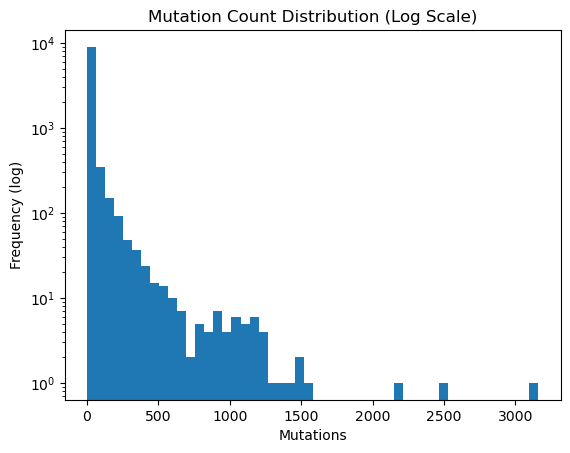

In [8]:
# %%
# Mutation count per sample
mutation_per_sample = mut_counts.sum(axis=0)

plt.figure()

plt.hist(mutation_per_sample, bins=50)
plt.yscale("log")  # log scale for frequency

plt.title("Mutation Count Distribution (Log Scale)")
plt.xlabel("Mutations")
plt.ylabel("Frequency (log)")

plt.show()

## Load Expression Data

E ∈ ℝ^{|G| × |S|}


In [9]:
# expr = pd.read_csv(
#     "../data/_xena/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena",
#     sep="\t"
# )
# expr.rename(columns={expr.columns[0]:"Gene"}, inplace=True)

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

EXPR_FILE = "../data/_xena/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena"

chunk_size = 5000
expr_list = []

reader = pd.read_csv(EXPR_FILE, sep="\t", chunksize=chunk_size)

for chunk in tqdm(reader, desc="Reading expression"):
    expr_list.append(chunk)

expr = pd.concat(expr_list, ignore_index=True)
expr.rename(columns={expr.columns[0]: "Gene"}, inplace=True)

print("✅ Loaded:", expr.shape)

Reading expression: 0it [00:00, ?it/s]

✅ Loaded: (20531, 11070)


: 

## Clean Expression Data

Remove zero genes and ensure numeric stability.


In [ ]:
# expr = expr.loc[(expr.iloc[:,1:] != 0).any(axis=1)]
# expr.columns = ["Gene"] + [c[:15] for c in expr.columns[1:]]
# expr_numeric = expr.drop(columns=["Gene"]).apply(pd.to_numeric, errors="coerce")
# expr_numeric = expr_numeric.groupby(expr_numeric.columns, axis=1).mean()
# expr = pd.concat([expr["Gene"], expr_numeric], axis=1)


In [ ]:
from tqdm.auto import tqdm

tqdm.pandas()

expr = expr.loc[
    expr.iloc[:, 1:].progress_apply(lambda row: (row != 0).any(), axis=1)
]

expr.columns = ["Gene"] + [c[:15] for c in expr.columns[1:]]

expr_numeric = expr.drop(columns=["Gene"]).progress_apply(pd.to_numeric, errors="coerce")

# expr_numeric = expr_numeric.T.groupby(level=0).mean().T
expr_numeric = expr_numeric.T.groupby(level=0).median().T

expr = pd.concat([expr["Gene"], expr_numeric], axis=1)

print("✅ Done:", expr.shape)

## Align Samples

S = intersection of mutation and expression samples


In [ ]:
common_samples = list(set(expr.columns[1:]) & set(mut_binary.columns))
expr = expr[["Gene"] + common_samples]
mut_binary = mut_binary[common_samples]



## Expression Normalization and Standardization

To ensure comparability across samples and genes, gene expression data are normalized and standardized in three steps.

### Log Transformation

Raw expression values are first transformed using a log-scale to stabilize variance and reduce the influence of extreme values:

$$
X'_{g,s} = \log(1 + X_{g,s})
$$

where $X_{g,s}$ denotes the expression of gene $g$ in sample $s$. This transformation compresses large values while preserving relative differences.

---

### Mean-Centering (Per Gene)

Next, each gene is centered by subtracting its mean expression across all samples:

$$
\tilde{X}_{g,s} = X'_{g,s} - \frac{1}{N} \sum_{s=1}^{N} X'_{g,s}
$$

This step removes baseline expression differences between genes, ensuring that each gene has zero mean across samples.

---

### Variance Scaling (Z-score Normalization)

Finally, the centered values are scaled by the standard deviation of each gene:

$$
Z_{g,s} = \frac{\tilde{X}_{g,s}}{\sigma_g + \epsilon}
$$

where $\sigma_g$ is the standard deviation of gene $g$, and $\epsilon$ is a small constant to prevent division by zero.

---

### Interpretation

The resulting matrix $Z_{g,s}$ represents standardized gene expression values where:
- Positive values indicate over-expression relative to the gene's mean
- Negative values indicate under-expression
- Values are comparable across genes and samples

<!-- This normalization is critical for downstream analyses such as dimensionality reduction (PCA, UMAP) and machine learning models, as it ensures that all genes contribute equally regardless of their original scale. -->

In [ ]:
expr_vals = expr.set_index("Gene")
expr_vals = np.log1p(expr_vals)
expr_vals = expr_vals.sub(expr_vals.mean(axis=1), axis=0)
expr_vals = expr_vals.div(expr_vals.std(axis=1) + 1e-8, axis=0)

/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [ ]:
# ----------------------------------
# Aggregate expression to cancer level
# ----------------------------------
def aggregate_expression_to_cancer(expr_vals, pheno):
    """
    expr_vals: gene × sample
    returns: gene × cancer
    """

    # ensure samples align
    common_samples = list(set(expr_vals.columns) & set(pheno["Sample"]))
    expr_vals = expr_vals[common_samples]
    pheno_sub = pheno[pheno["Sample"].isin(common_samples)]

    cancer_dict = {}

    for sample in common_samples:
        cancer = pheno_sub.loc[
            pheno_sub["Sample"] == sample, "Cancer"
        ].values

        if len(cancer) == 0:
            continue

        cancer = cancer[0]

        cancer_dict.setdefault(cancer, []).append(expr_vals[sample].values)

    cancers = sorted(cancer_dict.keys())

    matrix = np.array([
        np.mean(cancer_dict[c], axis=0)
        for c in cancers
    ]).T

    result = pd.DataFrame(matrix, columns=cancers)
    result.insert(0, "gene", expr_vals.index)

    return result


# Run aggregation
expr_cancer_df = aggregate_expression_to_cancer(expr_vals, pheno)

# merge duplicate genes
expr_cancer_df = expr_cancer_df.groupby("gene", as_index=False).mean()

print("Expression (gene × cancer):", expr_cancer_df.shape)

Expression (gene × cancer): (20530, 25)


In [ ]:
out_file = os.path.join(SAVE_DIR, "expression_features_mutation.csv")
expr_cancer_df.to_csv(out_file, index=False)

print("Saved:", out_file)

Saved: data/tcga/expression_features_mutation.csv


In [ ]:
def aggregate_mutation_to_cancer(mut_binary, pheno):

    common_samples = list(set(mut_binary.columns) & set(pheno["Sample"]))
    mut_binary = mut_binary[common_samples]
    pheno_sub = pheno[pheno["Sample"].isin(common_samples)]

    cancer_dict = {}

    for sample in common_samples:
        cancer = pheno_sub.loc[
            pheno_sub["Sample"] == sample, "Cancer"
        ].values

        if len(cancer) == 0:
            continue

        cancer = cancer[0]

        cancer_dict.setdefault(cancer, []).append(mut_binary[sample].values)

    cancers = sorted(cancer_dict.keys())

    matrix = np.array([
        np.mean(cancer_dict[c], axis=0)
        for c in cancers
    ]).T

    result = pd.DataFrame(matrix, columns=cancers)
    result.insert(0, "gene", mut_binary.index)

    return result


mut_cancer_df = aggregate_mutation_to_cancer(mut_binary, pheno)
mut_cancer_df = mut_cancer_df.groupby("gene", as_index=False).mean()

mut_cancer_df.to_csv(os.path.join(SAVE_DIR, "mutation_features.csv"), index=False)

print("Saved mutation features")

Saved mutation features


In [ ]:
# ===============================
# Automatic NaN Handling Pipeline
# ===============================

def clean_expression_matrix(X, drop_threshold=0.2):
    """
    Cleans expression matrix for downstream ML.

    Parameters:
    - X: DataFrame (genes × samples or samples × genes depending on use)
    - drop_threshold: max allowed NaN fraction per gene

    Returns:
    - Cleaned DataFrame
    """

    print("Initial shape:", X.shape)

    # Replace inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # Drop genes with too many NaNs
    nan_fraction = X.isna().mean(axis=1)
    X = X[nan_fraction < drop_threshold]

    print("After NaN threshold filtering:", X.shape)

    # Drop zero-variance genes
    X = X.loc[X.std(axis=1) > 0]

    print("After removing zero-variance genes:", X.shape)

    # Impute remaining NaNs (mean per gene)
    X = X.T  # transpose for sklearn
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(X)

    # Back to DataFrame
    X_clean = pd.DataFrame(X_imputed, index=X.index, columns=X.columns)

    print("Final cleaned shape:", X_clean.shape)

    return X_clean

# Clean expression matrix
X_clean = clean_expression_matrix(expr_vals)

# Transpose for PCA (samples × genes)
X = X_clean

Initial shape: (20531, 9173)
After NaN threshold filtering: (20415, 9173)
After removing zero-variance genes: (20195, 9173)
Final cleaned shape: (9173, 20195)


# PCA Explained Variance Ratio

Principal Component Analysis (PCA) projects high-dimensional data into a lower-dimensional space while preserving variance.

The **explained variance ratio** for each principal component is defined as:

\[
\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{k} \lambda_j}
\]

where:
- \( \lambda_i \) is the eigenvalue corresponding to the \(i\)-th principal component  
- \( k \) is the total number of components  

The **cumulative explained variance** is:

\[
\sum_{i=1}^{m} \frac{\lambda_i}{\sum_{j=1}^{k} \lambda_j}
\]

This measures how much of the total variance is captured by the first \( m \) components.

- High variance = important biological signal  
- Low variance = noise or redundant information  

This helps determine how many components are needed to represent the data effectively.

In [ ]:

pheno = pd.read_csv(PHENO_FILE, sep="\t", compression="gzip")

pheno["Sample"] = pheno["sample"]
pheno["_primary_disease"] = pheno["_primary_disease"].str.strip().str.lower()
pheno["Cancer"] = pheno["_primary_disease"].map(disease_to_tcga)
pheno = pheno.dropna(subset=["Cancer"])

print("Total mapped samples:", len(pheno))

# Ensure samples are rows
if X.shape[0] == len(expr_vals.index):
    # likely genes × samples → transpose
    X = X.T

# Ensure index is sample IDs
X.index = X.index.astype(str)

pheno["Sample"] = pheno["Sample"].astype(str)

sample_to_cancer = dict(zip(pheno["Sample"], pheno["Cancer"]))

# aligned labels (STRICT + SAFE)
cancer_labels = X.index.map(sample_to_cancer)

# remove unknowns (important for plots)
valid_mask = cancer_labels.notna()

X = X.loc[valid_mask]
cancer_labels = cancer_labels[valid_mask]



Total mapped samples: 9513


In [ ]:
# FINAL SAFE ALIGNMENT (DO THIS BEFORE PCA)

X = X.copy()
import pandas as pd

cancer_labels = pd.Series(
    [sample_to_cancer.get(s, "Unknown") for s in X.index],
    index=X.index
)

print("Aligned X:", X.shape)
print("Aligned labels:", len(cancer_labels))

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Aligned X: (6877, 20195)
Aligned labels: 6877


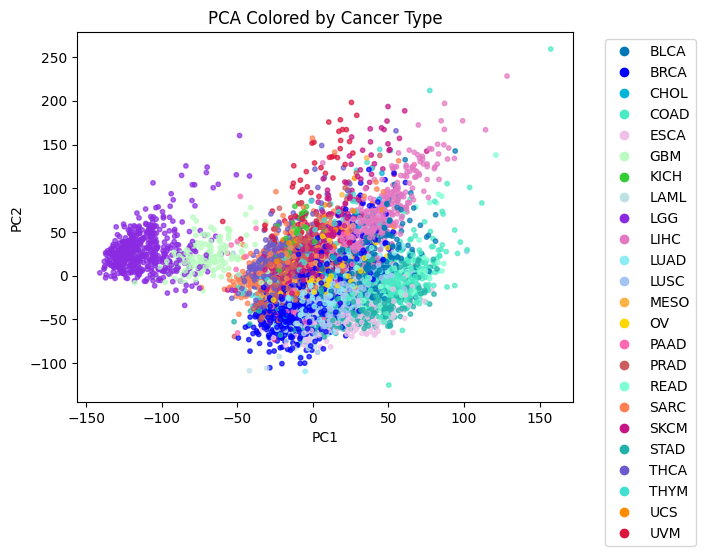

In [ ]:
unique_cancers = sorted(cancer_labels.unique())

color_map = {c: i for i, c in enumerate(unique_cancers)}
label_ids = cancer_labels.map(color_map).values

plot_colors = [COLORS[i % len(COLORS)] for i in label_ids]

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=plot_colors,
    s=10,
    alpha=0.7
)

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        label=c,
        color=COLORS[i % len(COLORS)]
    )
    for i, c in enumerate(unique_cancers)
]

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by Cancer Type")
plt.show()

/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


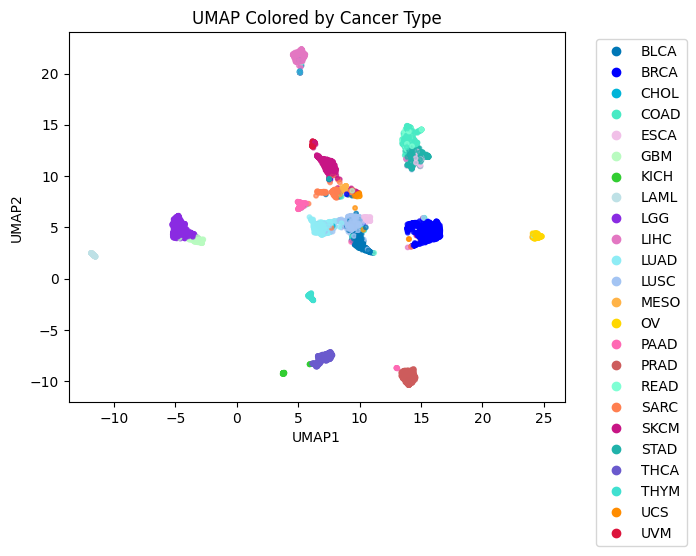

In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Ensure clean input
# ===============================
X_safe = X.replace([np.inf, -np.inf], np.nan).dropna()

# ===============================
# UMAP settings
# ===============================
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_safe)

# ===============================
# Cancer label mapping
# ===============================
unique_cancers = sorted(cancer_labels.unique())

color_map = {c: i for i, c in enumerate(unique_cancers)}
label_ids = cancer_labels.loc[X_safe.index].map(color_map).values

plot_colors = [COLORS[i % len(COLORS)] for i in label_ids]

plt.figure()

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=plot_colors,
    s=10,
    alpha=0.7
)

# ===============================
# Legend with consistent colors
# ===============================
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        label=c,
        color=COLORS[i % len(COLORS)]
    )
    for i, c in enumerate(unique_cancers)
]

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP Colored by Cancer Type")
plt.show()

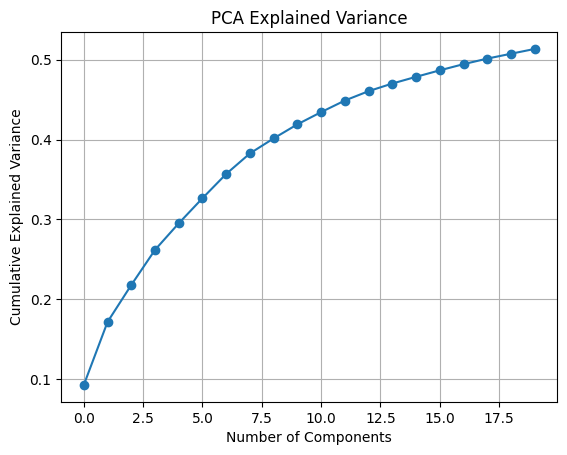

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale data
X_scaled = StandardScaler().fit_transform(X)

# Run PCA (keep more components for variance analysis)
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# ===============================
# 📊 Explained Variance Plot
# ===============================
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure()
plt.plot(cumulative_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()



## 🧭 UMAP

# Clustering Validation: Adjusted Rand Index (ARI)

To quantitatively evaluate how well the low-dimensional embeddings (PCA / UMAP) preserve biological structure, we compute the **Adjusted Rand Index (ARI)** between true cancer labels and unsupervised clustering results.

---

## Mathematical Definition

The ARI is defined as:

\[
ARI = \frac{RI - \mathbb{E}[RI]}{\max(RI) - \mathbb{E}[RI]}
\]

where:
- \( RI \): Rand Index measuring agreement between cluster assignments  
- \( \mathbb{E}[RI] \): expected agreement by chance  
- \( \max(RI) \): maximum possible agreement  

---

## Method

1. Project data into embedding space (PCA or UMAP)
2. Apply KMeans clustering:
   \[
   k = |\mathcal{C}|
   \]
   where \( \mathcal{C} \) is the set of cancer types
3. Compare cluster assignments with true cancer labels

---

## Interpretation

- **ARI ≈ 0.0** → no meaningful structure  
- **ARI 0.3–0.6** → moderate cancer separation  
- **ARI > 0.7** → strong biological signal preservation  

A higher ARI indicates that the embedding preserves **cancer-type–specific molecular structure**.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# use PCA space (or UMAP space)
X_embed = X_pca  # or X_umap

# cluster into same number of cancers
n_clusters = len(cancer_labels.unique())

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_embed)

# ground truth labels
true_labels = cancer_labels.astype(str)

ari = adjusted_rand_score(true_labels, cluster_ids)

print("Adjusted Rand Index (ARI):", ari)

Adjusted Rand Index (ARI): 0.64106183692749


# UMAP Embedding with Density Estimation

To capture both global and local structure of cancer-specific distributions, we visualize UMAP embeddings with **density estimation per cancer type**.

---

## Mathematical View

UMAP constructs a low-dimensional embedding by minimizing:

\[
\mathcal{L} = \sum_{i,j} w_{ij} \cdot \log \frac{p_{ij}}{q_{ij}}
\]

where:
- \( p_{ij} \): high-dimensional similarity  
- \( q_{ij} \): low-dimensional similarity  
- \( w_{ij} \): edge weight in fuzzy graph  

---

## Method

1. Compute UMAP embedding:
   \[
   X \rightarrow \mathbb{R}^2
   \]
2. Group samples by cancer type
3. Estimate density using kernel density estimation (KDE)
4. Overlay:
   - Scatter plot (individual samples)
   - Density contours (per cancer type)

---

## Interpretation

- Dense regions → high molecular similarity within cancer type  
- Overlapping densities → shared molecular signatures between cancers  
- Isolated clusters → distinct cancer subtypes  

This visualization highlights both:
- **local structure (within cancer types)**  
- **global relationships (between cancers)**  

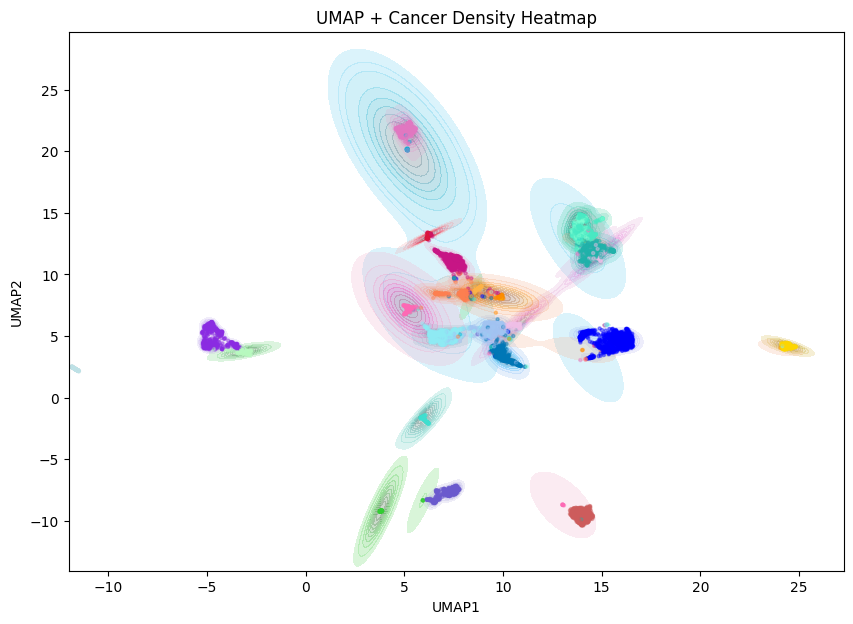

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 🧼 Ensure alignment
# ===============================
cancer_labels_aligned = cancer_labels.loc[X_safe.index]  # or X_umap index if available

unique_cancers = sorted(cancer_labels_aligned.unique())

color_map = {c: i for i, c in enumerate(unique_cancers)}

label_ids = cancer_labels_aligned.map(color_map).values

plot_colors = [COLORS[i % len(COLORS)] for i in label_ids]

# ===============================
# 📊 Plot
# ===============================
plt.figure(figsize=(10, 7))

# 🔥 KDE density per cancer (colored properly)
for i, c in enumerate(unique_cancers):
    mask = cancer_labels_aligned == c

    sns.kdeplot(
        x=X_umap[mask, 0],
        y=X_umap[mask, 1],
        fill=True,
        alpha=0.25,
        color=COLORS[i % len(COLORS)]
    )

# 🔵 scatter overlay
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=plot_colors,
    s=5,
    alpha=0.4
)

plt.title("UMAP + Cancer Density Heatmap")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

## Save Output

In [ ]:
# # maf.to_csv("TCGA-PAN.mutation.tsv", sep="\t", index=False)
# out_file = os.path.join(SAVE_DIR, "mutation_features.csv")
# maf.to_csv(out_file, index=False)

# print("Saved:", out_file)


Saved: data/tcga/mutation_features.csv


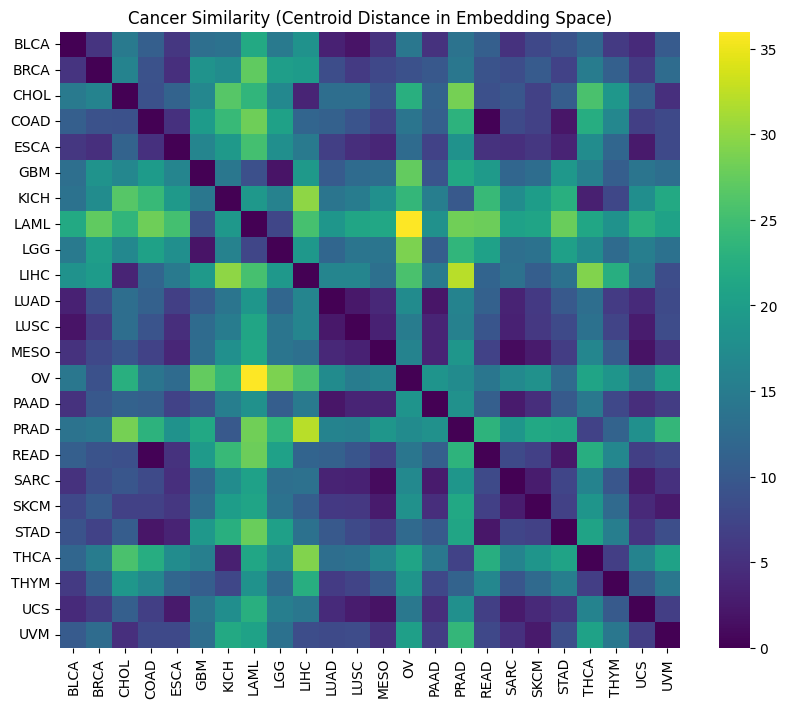

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# Compute centroids (UMAP or PCA space)
# ===============================
X_embed = X_umap  # or X_pca

centroids = {}
cancers = sorted(cancer_labels.unique())

for c in cancers:
    mask = cancer_labels == c
    centroids[c] = X_embed[mask].mean(axis=0)

centroid_matrix = np.array(list(centroids.values()))

# ===============================
# Pairwise distance matrix
# ===============================
dist_matrix = np.zeros((len(cancers), len(cancers)))

for i in range(len(cancers)):
    for j in range(len(cancers)):
        dist_matrix[i, j] = np.linalg.norm(
            centroid_matrix[i] - centroid_matrix[j]
        )

dist_df = pd.DataFrame(dist_matrix, index=cancers, columns=cancers)

# ===============================
# Plot heatmap
# ===============================
plt.figure(figsize=(10, 8))
sns.heatmap(dist_df, cmap="viridis")
plt.title("Cancer Similarity (Centroid Distance in Embedding Space)")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np

X_embed = X_pca  # or X_umap

k = len(cancer_labels.unique())

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_embed)

true_labels = cancer_labels.values

# ===============================
# Purity computation
# ===============================
def purity_score(y_true, y_pred):
    cluster_ids = np.unique(y_pred)
    total = 0

    for cluster in cluster_ids:
        idx = np.where(y_pred == cluster)[0]
        true_labels_cluster = y_true[idx]

        most_common = Counter(true_labels_cluster).most_common(1)[0][1]
        total += most_common

    return total / len(y_true)

purity = purity_score(true_labels, clusters)

print("Cluster Purity:", purity)

Cluster Purity: 0.7871164752072124


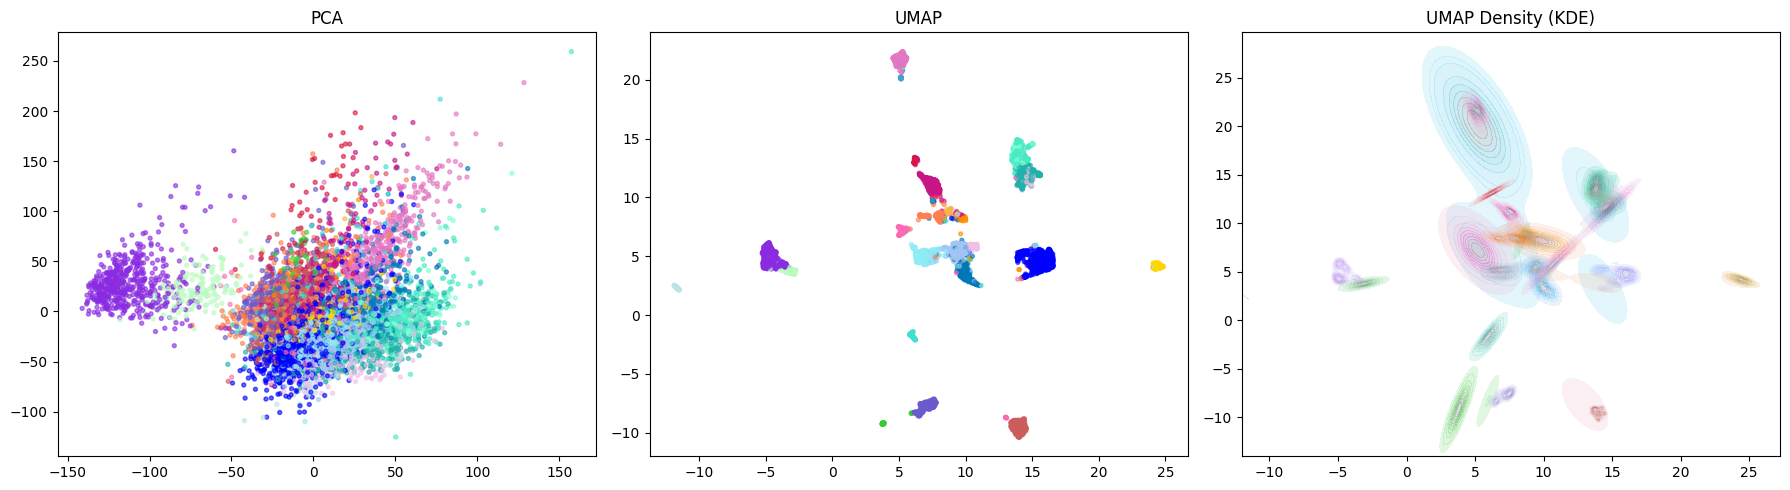

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ===============================
# 🎯 PCA
# ===============================
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[COLORS[i % len(COLORS)] for i in cancer_labels.map({c:i for i,c in enumerate(sorted(cancer_labels.unique()))})],
    s=8,
    alpha=0.6
)
axes[0].set_title("PCA")

# ===============================
# 🧭 UMAP
# ===============================
axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=[COLORS[i % len(COLORS)] for i in cancer_labels.map({c:i for i,c in enumerate(sorted(cancer_labels.unique()))})],
    s=8,
    alpha=0.6
)
axes[1].set_title("UMAP")

# ===============================
# 📊 KDE (density view)
# ===============================
for i, c in enumerate(sorted(cancer_labels.unique())):
    mask = cancer_labels == c
    sns.kdeplot(
        x=X_umap[mask, 0],
        y=X_umap[mask, 1],
        fill=True,
        alpha=0.2,
        color=COLORS[i % len(COLORS)],
        ax=axes[2]
    )

axes[2].set_title("UMAP Density (KDE)")

plt.tight_layout()
plt.show()

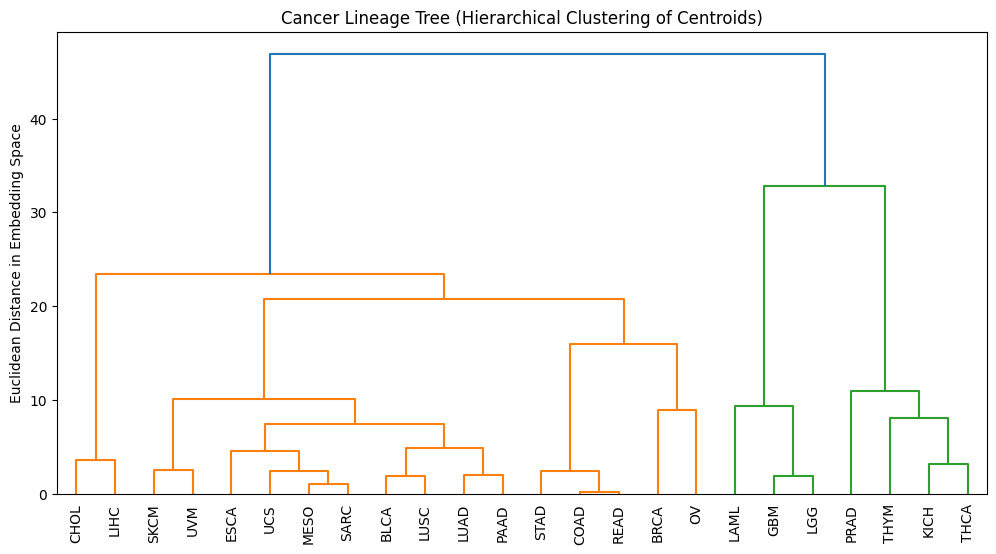

In [ ]:
import numpy as np

X_embed = X_umap  # or X_pca (UMAP is usually better here)

cancers = sorted(cancer_labels.unique())

centroids = []
for c in cancers:
    mask = cancer_labels == c
    centroids.append(X_embed[mask].mean(axis=0))

centroids = np.array(centroids)

from scipy.spatial.distance import pdist, squareform

dist_matrix = squareform(pdist(centroids, metric="euclidean"))

from scipy.cluster.hierarchy import linkage, dendrogram

# convert to condensed form
condensed = pdist(centroids, metric="euclidean")

Z = linkage(condensed, method="ward")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    labels=cancers,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Cancer Lineage Tree (Hierarchical Clustering of Centroids)")
plt.ylabel("Euclidean Distance in Embedding Space")
plt.show()



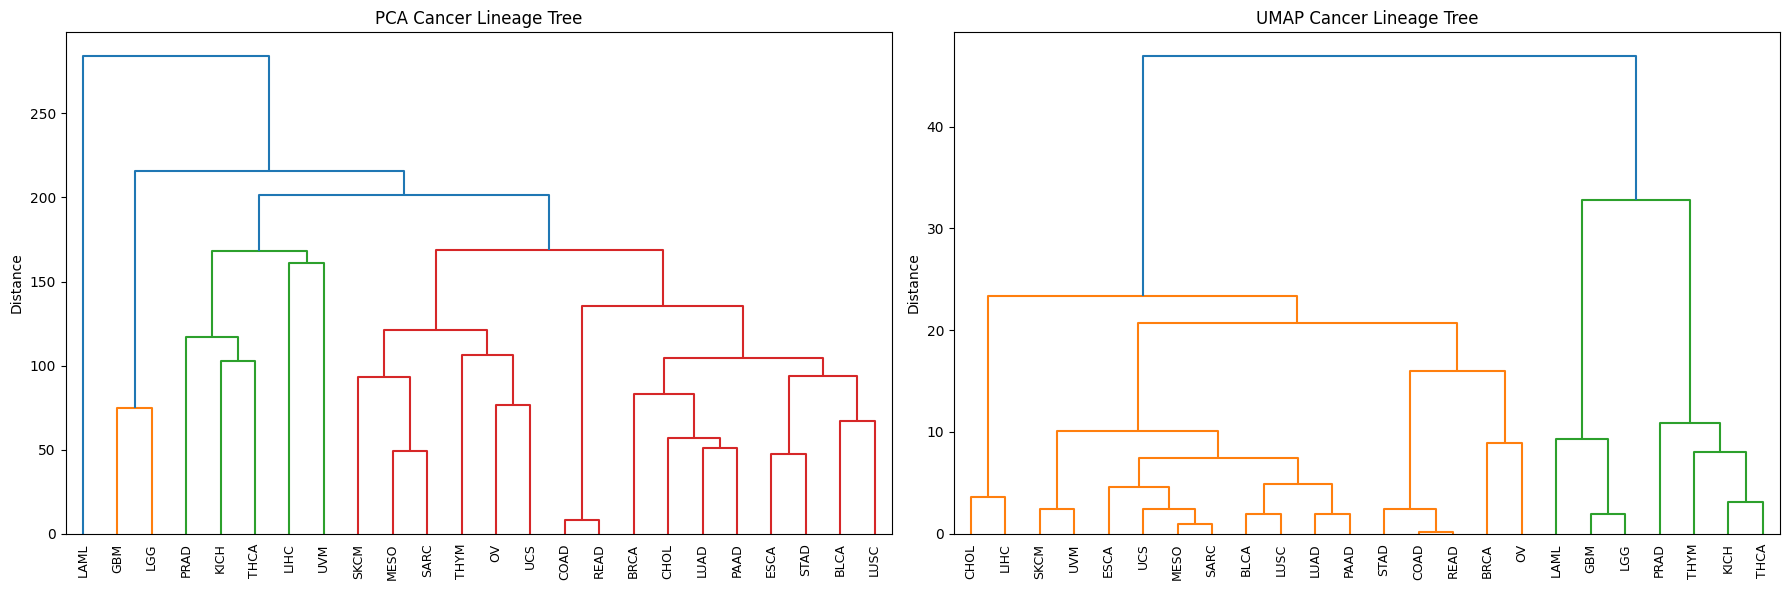

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

def build_tree(ax, X_embed, title):
    # centroids
    cancers = sorted(cancer_labels.unique())

    centroids = np.array([
        X_embed[cancer_labels == c].mean(axis=0)
        for c in cancers
    ])

    # clustering
    condensed = pdist(centroids, metric="euclidean")
    Z = linkage(condensed, method="ward")

    dendrogram(
        Z,
        labels=cancers,
        leaf_rotation=90,
        leaf_font_size=9,
        ax=ax
    )

    ax.set_title(title)
    ax.set_ylabel("Distance")

# ===============================
# Plot side-by-side
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

build_tree(axes[0], X_pca, "PCA Cancer Lineage Tree")
build_tree(axes[1], X_umap, "UMAP Cancer Lineage Tree")

plt.tight_layout()
plt.show()

In [ ]:
organ_map = {
    "BRCA": "Breast",
    "LUAD": "Lung", "LUSC": "Lung",
    "KIRC": "Kidney", "KIRP": "Kidney", "KICH": "Kidney",
    "COAD": "Gastrointestinal", "READ": "Gastrointestinal", "STAD": "Gastrointestinal",
    "GBM": "Brain", "LGG": "Brain",
    "LIHC": "Liver",
    "OV": "Gynecological",
    "UCEC": "Gynecological",
    "BLCA": "Urinary",
    "PRAD": "Prostate",
    "SKCM": "Skin",
    "THCA": "Thyroid",
}

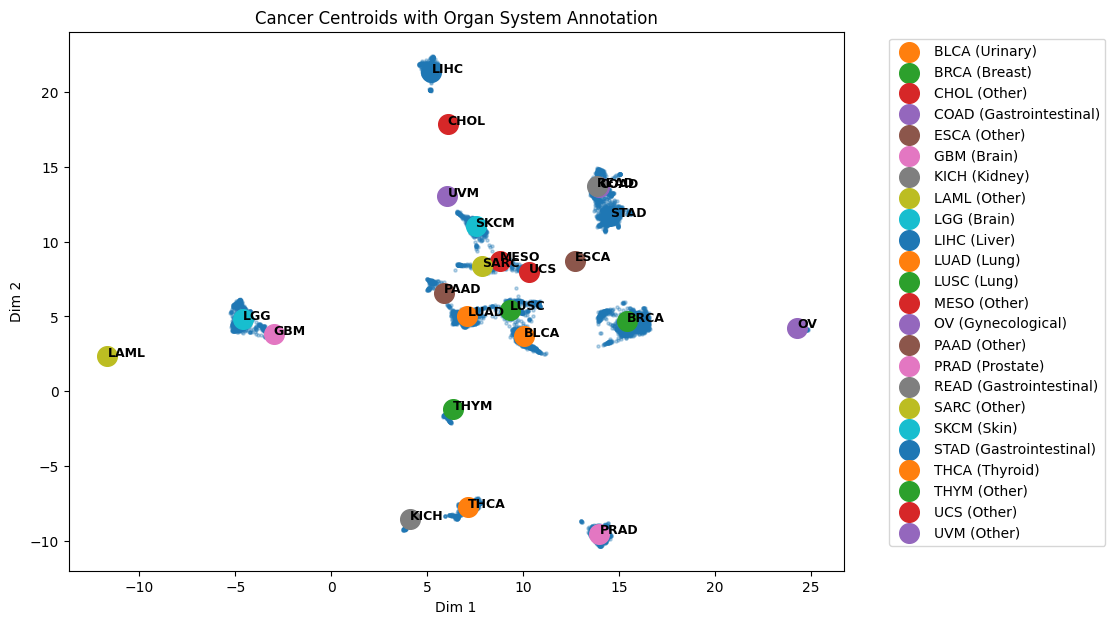

In [ ]:
import matplotlib.pyplot as plt

X_embed = X_umap  # or PCA

cancers = sorted(cancer_labels.unique())

centroids = np.array([
    X_embed[cancer_labels == c].mean(axis=0)
    for c in cancers
])

plt.figure(figsize=(10, 7))

plt.scatter(X_embed[:, 0], X_embed[:, 1], s=5, alpha=0.3)

for i, c in enumerate(cancers):
    org = organ_map.get(c, "Other")

    plt.scatter(
        centroids[i, 0],
        centroids[i, 1],
        s=200,
        label=f"{c} ({org})"
    )

    plt.text(
        centroids[i, 0],
        centroids[i, 1],
        c,
        fontsize=9,
        weight='bold'
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Cancer Centroids with Organ System Annotation")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [ ]:
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
import pandas as pd

# ===============================
# Use embedding space
# ===============================
X_embed = X_umap  # or PCA

# distance matrix
dist = squareform(pdist(X_embed, metric="euclidean"))

dm = DistanceMatrix(dist)

# metadata labels
groups = cancer_labels.values

# PERMANOVA test
result = permanova(dm, groups)

print(result)

method name                  PERMANOVA
test statistic name           pseudo-F
sample size                       6877
number of groups                    24
test statistic            11091.609915
p-value                          0.001
number of permutations             999
Name: PERMANOVA results, dtype: object


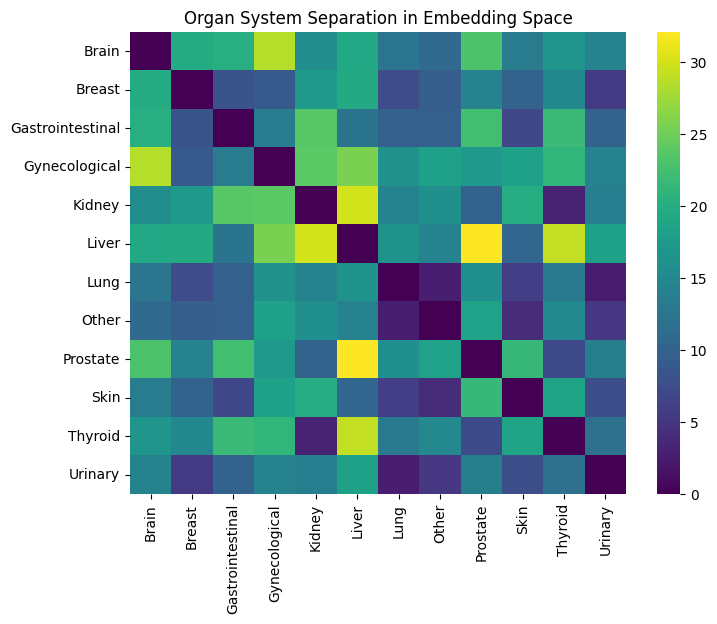

In [ ]:
import seaborn as sns
import numpy as np
from scipy.spatial.distance import pdist, squareform

# organ mapping (reuse yours)
organ_labels = cancer_labels.map(organ_map).fillna("Other")

organs = sorted(organ_labels.unique())

# compute organ centroids
centroids = np.array([
    X_umap[organ_labels == o].mean(axis=0)
    for o in organs
])

# distance matrix
D = squareform(pdist(centroids))

plt.figure(figsize=(8, 6))
sns.heatmap(D, xticklabels=organs, yticklabels=organs, cmap="viridis")

plt.title("Organ System Separation in Embedding Space")
plt.show()

In [ ]:
from collections import Counter

clusters = KMeans(n_clusters=len(cancers), random_state=42).fit_predict(X_umap)

gene_matrix = mut_binary  # gene × sample binary matrix

results = {}

for k in np.unique(clusters):
    idx = np.where(clusters == k)[0]
    cluster_samples = gene_matrix.columns[idx]

    cluster_genes = gene_matrix[cluster_samples].sum(axis=1)

    top_genes = cluster_genes.sort_values(ascending=False).head(20)

    results[k] = top_genes

# show one cluster example
print(results[0].head(10))

Gene
TP53     11
FAT1      7
APC       5
ATRX      5
LRP2      5
TTN       5
FBN2      4
CSMD3     4
UBR4      4
TBX3      4
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import gseapy as gp

In [ ]:
# clusters from embedding space
clusters = KMeans(
    n_clusters=len(cancer_labels.unique()),
    random_state=42,
    n_init=10
).fit_predict(X_umap)

gene_matrix = mut_binary  # genes × samples

cluster_gene_sets = {}

for k in np.unique(clusters):
    idx = np.where(clusters == k)[0]
    cluster_samples = gene_matrix.columns[idx]

    # sum mutation frequency per gene
    gene_scores = gene_matrix[cluster_samples].sum(axis=1)

    top_genes = gene_scores.sort_values(ascending=False).head(100).index.tolist()

    cluster_gene_sets[k] = top_genes

## 7. Pathway Enrichment Analysis (Reactome)

To interpret the biological meaning of each gene cluster, we perform pathway enrichment analysis using the Enrichr API (via `gseapy`).

### Objective

Given a set of genes for each cluster, identify significantly enriched biological pathways.

---

### Method

For each cluster \(k\), we analyze its gene set:

\[
G_k = \{ g_1, g_2, \dots, g_n \}
\]

Enrichment analysis evaluates whether genes in \(G_k\) are overrepresented in known pathways (e.g., Reactome).

---

### Output

For each cluster, Enrichr returns a table with:

- **Term**: Pathway name  
- **Adjusted P-value**: Significance after multiple testing correction  
- (Optional) Combined score, overlap, etc.

We focus on the most significant pathways:
\[
\text{Top pathways} = \arg\min (\text{Adjusted P-value})
\]

---

### Practical Considerations

- **API reliability**: Enrichr is an online service and may fail due to:
  - rate limiting  
  - network issues  
  - server downtime  

- **Retry strategy**:
  - Multiple attempts are used to ensure robustness  
  - A delay (`sleep`) is added between requests  

- **Gene set size**:
  - Very small gene sets (e.g., < 5 genes) may produce unstable results  

- **Gene format**:
  - Input genes must be standard gene symbols (e.g., TP53, EGFR)  
  - Ensembl IDs may not be recognized  

---

### Interpretation

This step connects computational clustering to biological insight:

- Clusters → gene modules  
- Enrichment → functional pathways  

Thus, each cluster can be interpreted in terms of:
- signaling pathways  
- cellular processes  
- disease mechanisms  

---

### Role in Pipeline

This analysis provides biological validation for:

- clustering results  
- saliency-based gene selection  
- multi-omics integration  

and helps identify functionally coherent gene groups.

In [ ]:
# %%
from tqdm import tqdm
import time

enrichment_results = {}

for cluster_id, genes in tqdm(cluster_gene_sets.items(), desc="Running Enrichment"):

    if len(genes) == 0:
        continue

    success = False

    for attempt in range(3):  # retry up to 3 times
        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets="Reactome_2022",
                organism="Human",
                outdir=None
            )

            enrichment_results[cluster_id] = enr.results

            print(f"\nCluster {cluster_id} (n={len(genes)})")
            print(
                enr.results
                .sort_values("Adjusted P-value")[["Term", "Adjusted P-value"]]
                .head(5)
            )

            success = True
            break

        except Exception as e:
            print(f"⚠️ Cluster {cluster_id}, attempt {attempt+1} failed: {e}")
            time.sleep(3)  # wait before retry

    if not success:
        print(f"❌ Skipping cluster {cluster_id} after 3 failed attempts")

Running Enrichment:   4%|▍         | 1/24 [00:02<00:52,  2.28s/it]


Cluster 0 (n=100)
                                                Term  Adjusted P-value
0          Chromatin Modifying Enzymes R-HSA-3247509      8.182859e-09
1      PKMTs Methylate Histone Lysines R-HSA-3214841      9.926087e-07
2  Transcriptional Regulation By RUNX1 R-HSA-8878171      1.195037e-06
3         Generic Transcription Pathway R-HSA-212436      5.079800e-05
4        Gene Expression (Transcription) R-HSA-74160      6.555847e-05


Running Enrichment:   8%|▊         | 2/24 [00:06<01:14,  3.39s/it]


Cluster 1 (n=100)
                                                Term  Adjusted P-value
0          Chromatin Modifying Enzymes R-HSA-3247509          0.000002
1      PKMTs Methylate Histone Lysines R-HSA-3214841          0.000037
2  Transcriptional Regulation By RUNX1 R-HSA-8878171          0.000171
3         Generic Transcription Pathway R-HSA-212436          0.003287
4  RUNX1 Interacts With Co-Factors Whose Precise ...          0.003287


Running Enrichment:  12%|█▎        | 3/24 [00:08<01:02,  2.98s/it]

...


Cluster 21 (n=100)
                                                Term  Adjusted P-value
0  Transcriptional Regulation By RUNX1 R-HSA-8878171          0.004870
1          Chromatin Modifying Enzymes R-HSA-3247509          0.005214
2  RUNX1 Interacts With Co-Factors Whose Precise ...          0.005214
3                    Muscle Contraction R-HSA-397014          0.007901
4                       Heme Signaling R-HSA-9707616          0.007901


Running Enrichment:  96%|█████████▌| 23/24 [00:54<00:01,  1.92s/it]


Cluster 22 (n=100)
                                                Term  Adjusted P-value
0      PKMTs Methylate Histone Lysines R-HSA-3214841          0.001959
1          Chromatin Modifying Enzymes R-HSA-3247509          0.005648
2                    RHOV GTPase Cycle R-HSA-9013424          0.005648
3                    RHOU GTPase Cycle R-HSA-9013420          0.005648
4  RUNX1 Regulates Genes Involved In Megakaryocyt...          0.032612


Running Enrichment: 100%|██████████| 24/24 [00:56<00:00,  2.35s/it]


Cluster 23 (n=100)
                                                Term  Adjusted P-value
0                              Disease R-HSA-1643685          0.000565
1  Diseases Of Signal Transduction By Growth Fact...          0.002568
2  RUNX1 Regulates Genes Involved In Megakaryocyt...          0.003107
3          Oncogene Induced Senescence R-HSA-2559585          0.003107
4                    Muscle Contraction R-HSA-397014          0.006676


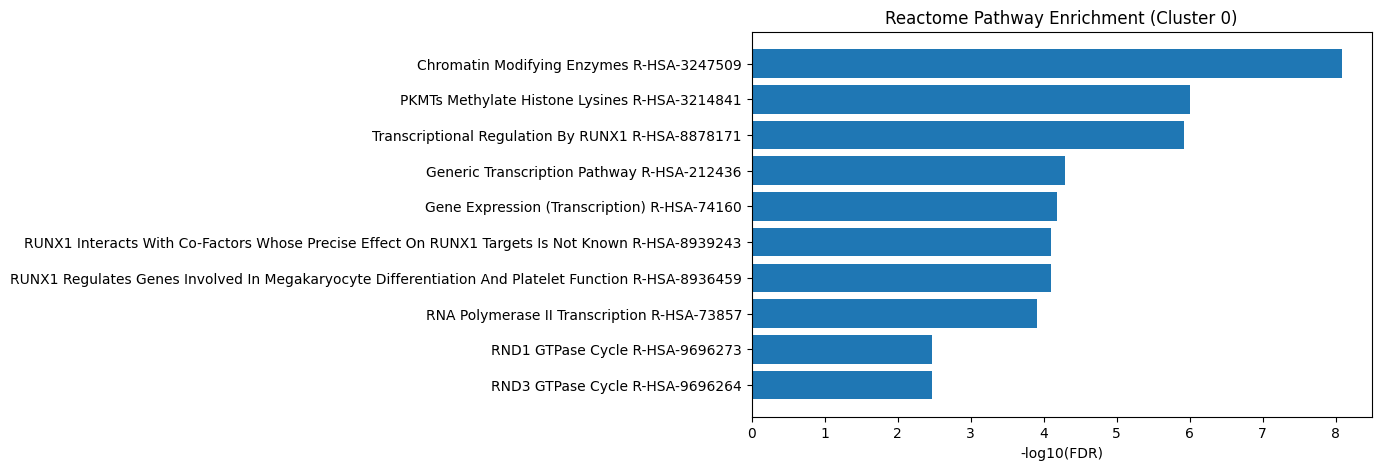

In [ ]:
import matplotlib.pyplot as plt

cluster_id = list(enrichment_results.keys())[0]

df = enrichment_results[cluster_id].head(10)

plt.figure(figsize=(8, 5))
plt.barh(df["Term"], -np.log10(df["Adjusted P-value"]))

plt.xlabel("-log10(FDR)")
plt.title(f"Reactome Pathway Enrichment (Cluster {cluster_id})")
plt.gca().invert_yaxis()
plt.show()

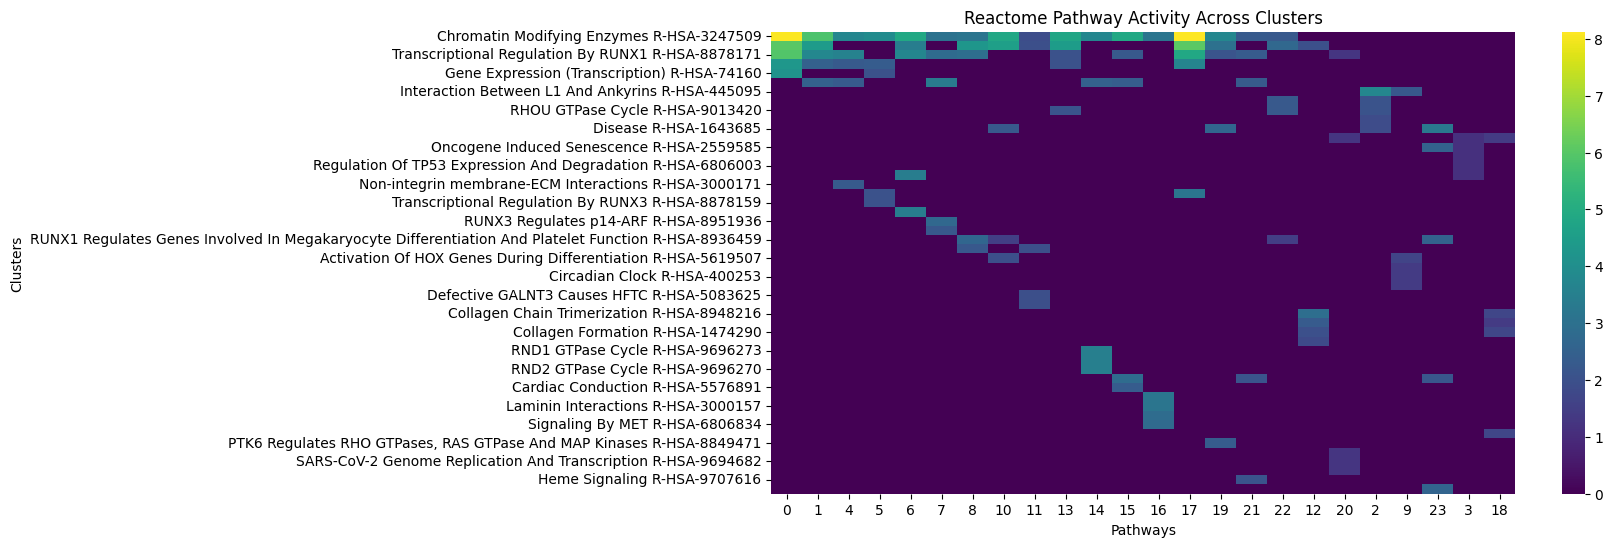

In [ ]:
import seaborn as sns

all_terms = {}

for cid, res in enrichment_results.items():
    top = res.head(5)
    for _, row in top.iterrows():
        all_terms.setdefault(row["Term"], {})[cid] = -np.log10(row["Adjusted P-value"])

df = pd.DataFrame(all_terms).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(df.T, cmap="viridis")

plt.title("Reactome Pathway Activity Across Clusters")
plt.xlabel("Pathways")
plt.ylabel("Clusters")
plt.show()